## Modelo predicctor de BIS

[INFO] Dispositivo: cuda
[INFO] GPU: NVIDIA GeForce RTX 5060
[INFO] VRAM disponible: 8.0 GB

[INFO] Cargando datasets en GPU...
  Cargando C:\Users\yordi\Desktop\dataset_entrenamiento.pt ...
  Listo: 501,192 muestras | 1386 MB en cuda | 0.6 s
  Cargando C:\Users\yordi\Desktop\dataset_validacion.pt ...
  Listo: 137,204 muestras | 379 MB en cuda | 0.1 s
  Cargando C:\Users\yordi\Desktop\dataset_prueba.pt ...
  Listo: 38,945 muestras | 108 MB en cuda | 0.0 s
[INFO] Estadísticas de normalización (conjunto de entrenamiento):
  propofol      : media = 0.00512937, desviación estándar = 0.00783327
  remifentanilo : media = 0.00602943, desviación estándar = 0.00732605
  bis           : media = 44.9932, desviación estándar = 12.6622

[INFO] Parametros del modelo: 144,212
[INFO] Construyendo distribucion LDS...

  ENTRENAMIENTO

[Epoca 1/25]
    Lote [  20/3916] LDS=161.3278  MSE-aux=2568.0234
    Lote [  40/3916] LDS=194.7290  MSE-aux=2725.7354
    Lote [  60/3916] LDS=121.4098  MSE-aux=2480.299

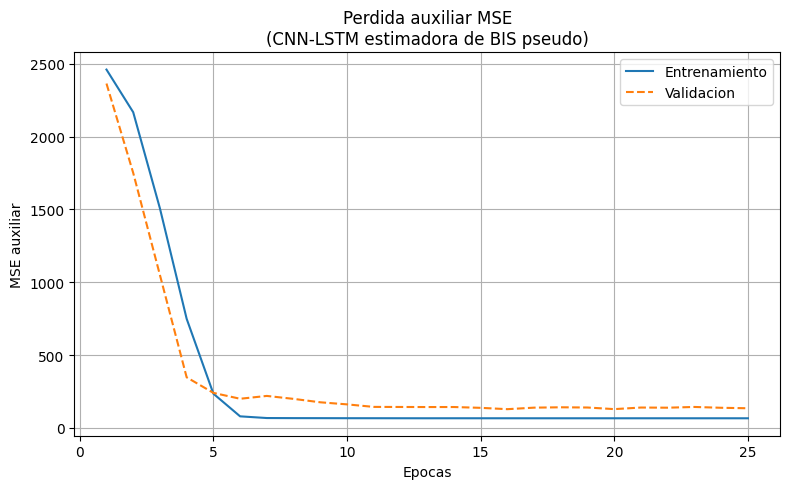

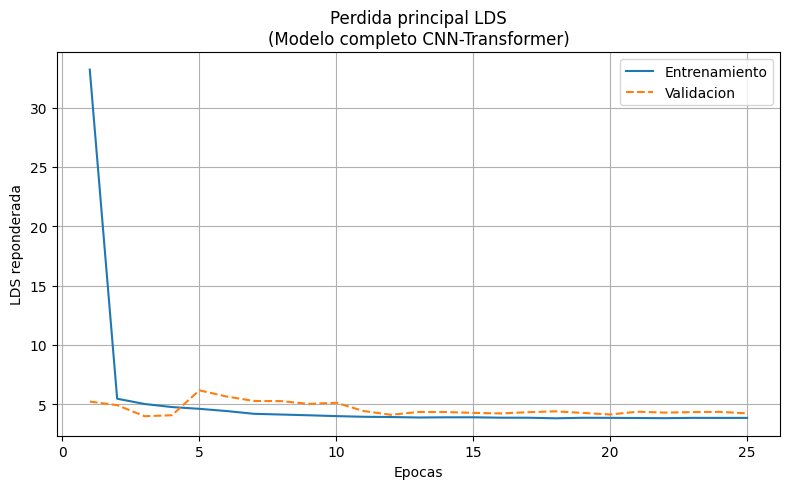


[INFO] Entrenamiento finalizado.


In [1]:
"""
Entrenamiento del modelo de prediccion de profundidad de anestesia .

Este es un modelo tipo trasnformer que combina CNN 1D, LSTM, GRN y atencion multicabeza 
del tipo PK -PD. Se entrena para predecir la profundidad de anestesia (BIS) a partir de las tasas de infusion de propofol y remifentanil, 
el historial de BIS y las covariables del paciente (edad, peso, altura, sexo).

Arquitectura:
  Bloque A : CNN 1D Cinetica + CNN 1D Dinamica → BIS pseudo-historico
  Bloque B : LSTM × 3 (propofol, remifentanil, BIS pseudo) + GRN
  Bloque C : Atencion multicabeza interpretable + Bottleneck

Funciones de perdida:
  - MSE auxiliar : BIS pseudo vs. BIS historico real (actualiza CNN)
  - LDS-MSE      : prediccion final con pesos inversos a la densidad
"""

# =============================================================================
# HIPERPARAMETROS
# =============================================================================
TASA_APRENDIZAJE    = 0.00005
EPOCAS              = 25
TAMANIYO_LOTE       = 128        
TAMANIYO_VENTANA    = 180          # Tamaño de la ventana que ve el modelo 
UNIDADES_LSTM       = 64
UNIDADES_GRN        = 64
CABEZAS_ATENCION    = 4
DROPOUT             = 0.35
LAMBDA_AUXILIAR     = 5.0          # Peso perdida MSE auxiliar (CNN)
LAMBDA_PRINCIPAL    = 20.0         # Peso perdida LDS principal
ANCHO_BANDA_LDS     = 12.0         # Sigma del kernel gaussiano LDS
PASO_DECAIMIENTO_LR = 6            # Cada cuantas epocas decae el LR
GAMMA_LR            = 0.2          # Factor de decaimiento del LR
GUARDAR_MODELO      = r"C:\Users\yordi\Desktop\modeloBIS.pt"

#--------------------------------------------------------------

# --- Hiperparametros CNN Cinetica (infusiones: propofol + remifentanil) ---
# Capa 1: Conv1d(2 → FILTROS_CIN_C1) + BN + ELU
# Capa 2: Conv1d(FILTROS_CIN_C1 → 1, kernel=1)  [proyeccion a Ce]

FILTROS_CIN_C1      = 16         # Numero de filtros de la primera capa
KERNEL_CIN_C1       = 5          # Tamaño del kernel de la primera capa            

# --- Hiperparametros CNN Dinamica (historial BIS → parametros W0..W3) ---
# Capa 1: Conv1d(1 → FILTROS_DIN_C1) + BN + ReLU
# Capa 2: Conv1d(FILTROS_DIN_C1 → FILTROS_DIN_C2) + BN + ReLU
# → AdaptiveAvgPool1d(1) → Flatten → MLP → 4 parametros

FILTROS_DIN_C1      = 12         # Filtros de la primera capa convolucional
KERNEL_DIN_C1       = 9          # Kernel de la primera capa
FILTROS_DIN_C2      = 6         # Filtros de la segunda capa convolucional
KERNEL_DIN_C2       = 5          # Kernel de la segunda capa


# Rutas a los archivos .pt generados por preprocesar_datos.py
RUTA_PT_ENTRENAMIENTO = r"C:\Users\yordi\Desktop\dataset_entrenamiento.pt"
RUTA_PT_VALIDACION    = r"C:\Users\yordi\Desktop\dataset_validacion.pt"
RUTA_PT_PRUEBA        = r"C:\Users\yordi\Desktop\dataset_prueba.pt"

# =============================================================================
# IMPORTACIONES
# =============================================================================
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# =============================================================================
# CONFIGURACION DEL DISPOSITIVO
# =============================================================================
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Dispositivo: {dispositivo}")
if dispositivo.type == "cuda":
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"[INFO] VRAM disponible: "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB"
    )

# =============================================================================
# DATASET EN MEMORIA GPU 
# =============================================================================
class DatasetGPU(Dataset):
    """
    Carga el archivo .pt completo y mueve todos los tensores a la GPU
    al momento de la inicializacion. Durante el entrenamiento, cada
    __getitem__ devuelve slices directamente desde VRAM, sin ningun
    movimiento de datos CPU → GPU en el bucle de entrenamiento.

    Entradas del archivo .pt (generado por Crea_tensores_pytorch.ipynb):
        infusiones   : (N, 2, W)  float16  — tasas con normalización global
        bis_hist     : (N, W)     float16  — historial con normalización global
        bis_hist_gt  : (N, W)     float32  — historial en unidades de BIS
        covariables  : (N, 4)     float32
        etiquetas    : (N,)       float32  — BIS en el instante siguiente
        estadisticas : dict                — parámetros de normalización
    """

    def __init__(self, ruta_pt: str, dispositivo: torch.device):
        print(f"  Cargando {ruta_pt} ...")
        t0      = time.time()
        datos   = torch.load(ruta_pt, map_location="cpu",
                             weights_only=True)

        # Mover todo a GPU 
        self.infusiones  = datos["infusiones"].to(
            dispositivo, dtype=torch.float32, non_blocking=True
        )
        self.bis_hist    = datos["bis_hist"].to(
            dispositivo, dtype=torch.float32, non_blocking=True
        )
        self.bis_hist_gt = datos["bis_hist_gt"].to(
            dispositivo, non_blocking=True
        )
        self.covariables = datos["covariables"].to(
            dispositivo, non_blocking=True
        )
        self.etiquetas   = datos["etiquetas"].to(
            dispositivo, non_blocking=True
        )
        # Parámetros de normalización con que se construyó el conjunto
        self.estadisticas = datos.get("estadisticas")
        if self.estadisticas is None:
            raise KeyError(
                f"El archivo {ruta_pt} no contiene las estadísticas de "
                "normalización; debe generarse con Crea_tensores_pytorch.ipynb."
            )

        n = len(self.etiquetas)
        mb = sum(
            t.nbytes for t in [
                self.infusiones, self.bis_hist, self.bis_hist_gt,
                self.covariables, self.etiquetas
            ]
        ) / 1024**2

        print(
            f"  Listo: {n:,} muestras | "
            f"{mb:.0f} MB en {dispositivo} | "
            f"{time.time() - t0:.1f} s"
        )

    def __len__(self):
        return len(self.etiquetas)

    def __getitem__(self, idx):
        return (
            self.infusiones[idx],
            self.bis_hist[idx],
            self.bis_hist_gt[idx],
            self.covariables[idx],
            self.etiquetas[idx],
        )


# =============================================================================
# BLOQUE A — CNN CINETICA
# =============================================================================
class CNNCinetica(nn.Module):
    """
    Estima la concentracion inicial en sitio efector (Ce) a partir de
    las tasas de infusion de propofol y remifentanil.

    Flujo interno:
        Conv1d(2 → F_C1, k=K_C1, padding='same') → BN1d → ELU → ReLU
        Conv1d(F_C1 → 1, k=1)                    [proyeccion a Ce bruta]

    La serie Ce bruta resultante es refinada posteriormente por una GRN
    que incorpora las covariables del paciente (ver EstimadorBISPseudo).

    Entrada : (Batch, 2, T)
    Salida  : (Batch, T)     — Ce bruta antes del refinamiento GRN

    Parametros establecidos desde los hiperparametros globales:
        FILTROS_CIN_C1, KERNEL_CIN_C1
    """

    def __init__(
        self,
        filtros_c1 = FILTROS_CIN_C1,
        kernel_c1  = KERNEL_CIN_C1,
    ):
        super().__init__()
        padding = kernel_c1 // 2   # Mantiene la longitud temporal 

        # Capa 1: convolucion + normalizacion por lote + activacion
        self.capa1 = nn.Sequential(
            nn.Conv1d(
                in_channels  = 2,
                out_channels = filtros_c1,
                kernel_size  = kernel_c1,
                padding      = padding,
                bias         = False,   # BN absorbe el sesgo
            ),
            nn.BatchNorm1d(filtros_c1),
            nn.ELU(),
        )

        # Capa 2: proyeccion puntual a un unico canal (Ce bruta)
        self.capa2 = nn.Conv1d(
            in_channels  = filtros_c1,
            out_channels = 1,
            kernel_size  = 1,
        )

    def forward(self, x):
        """
        x  : (Batch, 2, T)
        Retorna ce_bruta : (Batch, T)
        """
        return self.capa2(self.capa1(x)).squeeze(1)   # (Batch, T)


# =============================================================================
# BLOQUE A — GRN DE REFINAMIENTO CINETICO
# =============================================================================
class GRNCinetica(nn.Module):
    """
    Refina la serie Ce_k producida por la CNN cinetica incorporando las
    covariables fisiologicas del paciente como contexto externo.

    Corresponde al esquema GRN donde:
        Input 1 (x_t^par, conexion residual) : Ce_k  — serie (Batch, T, 1)
        Input 2 (ex_t, contexto externo)     : covariables del paciente
                                               — (Batch, 4)

    Flujo (por paso temporal, procesado en paralelo sobre T):
        a = Ce_k expandido a (Batch, T, 1)  →  Dense(1 → dim_oculta)
            + contexto Dense(4 → dim_oculta)
            → ELU → Dense → Gate (GLU) → Add & Norm  [conexion residual]
        Salida: (Batch, T, 1)  →  exprimido a (Batch, T)

    Se reutiliza la clase GRN general del modelo con:
        dim_entrada  = 1          (un escalar Ce_k por paso temporal)
        dim_oculta   = UNIDADES_GRN
        dim_salida   = 1          (Ce_k refinada, misma dimension)
        dim_contexto = 4          (covariables: Edad, Peso, Altura, Sexo)
    """

    def __init__(
        self,
        dim_oculta   = UNIDADES_GRN,
        dim_contexto = 4,
        tasa_dropout = DROPOUT,
    ):
        super().__init__()
        # GRN con entrada escalar por paso temporal y contexto de covariables
        self.grn = GRN(
            dim_entrada  = 1,
            dim_oculta   = dim_oculta,
            dim_salida   = 1,
            dim_contexto = dim_contexto,
            tasa_dropout = tasa_dropout,
        )

    def forward(self, ce_bruta, covariables):
        """
        ce_bruta    : (Batch, T)    — Ce_k sin refinar (Input 1 / residual)
        covariables : (Batch, 4)    — covariables del paciente  (Input 2)
        Retorna ce_refinada : (Batch, T)
        """
        # Expandir Ce_k a formato de secuencia para la GRN
        ce_seq     = ce_bruta.unsqueeze(-1)          # (Batch, T, 1)

        # La GRN procesa cada paso temporal con el mismo vector de contexto;
        # la expansion del contexto a (Batch, 1, dim_oculta) se realiza
        # internamente en GRN.forward cuando a.dim()==3 y c.dim()==2
        ce_ref_seq = self.grn(ce_seq, covariables)   # (Batch, T, 1)

        return ce_ref_seq.squeeze(-1)                 # (Batch, T)


# =============================================================================
# BLOQUE A — CNN DINAMICA
# =============================================================================
class CNNDinamica(nn.Module):
    """
    Procesa el historial de BIS y estima los parametros escalares
    [W0, W1, W2, W3] de la ecuacion del BIS pseudo-historico.

    Flujo:
        Conv1d(1 → F_C1, k=K_C1, padding='same') → BN1d → ReLU
        Conv1d(F_C1 → F_C2, k=K_C2, padding='same') → BN1d → ReLU
        AdaptiveAvgPool1d(1) → Flatten
        MLP: F_C2 → F_C2 → 4

    Entrada : (Batch, T)
    Salida  : (Batch, 4)  — parametros [W0, W1, W2, W3]

    Parametros establecidos desde los hiperparametros globales:
        FILTROS_DIN_C1, KERNEL_DIN_C1,
        FILTROS_DIN_C2, KERNEL_DIN_C2
    """

    def __init__(
        self,
        filtros_c1 = FILTROS_DIN_C1,
        kernel_c1  = KERNEL_DIN_C1,
        filtros_c2 = FILTROS_DIN_C2,
        kernel_c2  = KERNEL_DIN_C2,
    ):
        super().__init__()

        # Capa convolucional 1
        self.conv1 = nn.Sequential(
            nn.Conv1d(
                in_channels  = 1,
                out_channels = filtros_c1,
                kernel_size  = kernel_c1,
                padding      = kernel_c1 // 2,
                bias         = False,
            ),
            nn.BatchNorm1d(filtros_c1),
            nn.ReLU(),
        )

        # Capa convolucional 2
        self.conv2 = nn.Sequential(
            nn.Conv1d(
                in_channels  = filtros_c1,
                out_channels = filtros_c2,
                kernel_size  = kernel_c2,
                padding      = kernel_c2 // 2,
                bias         = False,
            ),
            nn.BatchNorm1d(filtros_c2),
            nn.ReLU(),
        )

        # Reduccion espacial y estimacion de parametros
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.aplanar = nn.Flatten()
        self.mlp     = nn.Sequential(
            nn.Linear(filtros_c2, filtros_c2),
            nn.ReLU(),
            nn.Linear(filtros_c2, 4),
        )

    def forward(self, bis_hist):
        """
        bis_hist : (Batch, T)
        Retorna  : (Batch, 4)
        """
        x = bis_hist.unsqueeze(1)               # (Batch, 1, T)
        h = self.pool(self.conv2(self.conv1(x))) # (Batch, F_C2, 1)
        return self.mlp(self.aplanar(h))         # (Batch, 4)


# =============================================================================
# BLOQUE A — ESTIMADOR BIS PSEUDO-HISTORICO
# =============================================================================
class EstimadorBISPseudo(nn.Module):
    """
    Produce la serie BIS pseudo-historica que sustituye a las predicciones
    del modelo PK-PD clasico.

    Flujo completo del Bloque A:
        1. CNNCinetica   : infusiones (Batch,2,T) → Ce_bruta (Batch,T)
        2. GRNCinetica   : Ce_bruta + covariables → Ce_refinada (Batch,T)
                           [Input 1 = Ce_bruta en conexion residual,
                            Input 2 = covariables como contexto externo]
        3. CNNDinamica   : bis_hist  (Batch,T)   → [W0,W1,W2,W3] (Batch,4)
        4. Ecuacion BIS  : BIS_k = W0 + W1 * sigmoid(W2 * Ce_refinada_k + W3)

    La Ce refinada por la GRN es la que alimenta la ecuacion del BIS
    y es la que finalmente ingresa a la LSTM del Bloque B.
    """

    def __init__(
        self,
        filtros_cin_c1 = FILTROS_CIN_C1,
        kernel_cin_c1  = KERNEL_CIN_C1,
        filtros_din_c1 = FILTROS_DIN_C1,
        kernel_din_c1  = KERNEL_DIN_C1,
        filtros_din_c2 = FILTROS_DIN_C2,
        kernel_din_c2  = KERNEL_DIN_C2,
        dim_covariables = 4,
        dim_oculta_grn  = UNIDADES_GRN,
        tasa_dropout    = DROPOUT,
    ):
        super().__init__()

        # Paso 1: extraccion de Ce bruta desde las infusiones
        self.cnn_cinetica = CNNCinetica(
            filtros_c1 = filtros_cin_c1,
            kernel_c1  = kernel_cin_c1,
        )

        # Paso 2: refinamiento de Ce con covariables del paciente (GRN)
        self.grn_cinetica = GRNCinetica(
            dim_oculta   = dim_oculta_grn,
            dim_contexto = dim_covariables,
            tasa_dropout = tasa_dropout,
        )

        # Paso 3: estimacion de parametros W0..W3 desde historial BIS
        self.cnn_dinamica = CNNDinamica(
            filtros_c1 = filtros_din_c1,
            kernel_c1  = kernel_din_c1,
            filtros_c2 = filtros_din_c2,
            kernel_c2  = kernel_din_c2,
        )

    def forward(self, infusiones, bis_hist, covariables):
        """
        infusiones  : (Batch, 2, T)
        bis_hist    : (Batch, T)
        covariables : (Batch, 4)
        Retorna:
            bis_pseudo  : (Batch, T)  — BIS estimado en toda la ventana
            ce_refinada : (Batch, T)  — Ce tras el refinamiento GRN
        """
        # Paso 1: Ce bruta desde la CNN cinetica
        ce_bruta    = self.cnn_cinetica(infusiones)          # (Batch, T)

        # Paso 2: Ce refinada incorporando covariables del paciente
        # (Ce_bruta actua como Input 1 / conexion residual en el GRN;
        #  las covariables actuan como Input 2 / contexto externo)
        ce_refinada = self.grn_cinetica(ce_bruta, covariables)  # (Batch, T)

        # Paso 3: parametros de la ecuacion BIS desde historial
        params = self.cnn_dinamica(bis_hist)                 # (Batch, 4)
        W0, W1, W2, W3 = (params[:, i:i+1] for i in range(4))

        # Paso 4: BIS pseudo-historico con la Ce refinada
        bis_pseudo = W0 + W1 * torch.sigmoid(
            W2 * ce_refinada + W3
        )                                                    # (Batch, T)

        return bis_pseudo, ce_refinada


# =============================================================================
# BLOQUE B — GRN
# =============================================================================
class GRN(nn.Module):
    """
    Gated Residual Network del Temporal Fusion Transformer.
    Fusiona informacion temporal con covariables estaticas del paciente
    mediante un mecanismo de compuerta (GLU) y conexion residual.
    """

    def __init__(self, dim_entrada, dim_oculta, dim_salida,
                 dim_contexto=None, tasa_dropout=DROPOUT):
        super().__init__()
        self.fc1       = nn.Linear(dim_entrada, dim_oculta)
        self.fc2       = nn.Linear(dim_oculta,  dim_oculta)
        self.fc_salida = nn.Linear(dim_oculta,  dim_salida * 2)
        self.norm      = nn.LayerNorm(dim_salida)
        self.dropout   = nn.Dropout(tasa_dropout)
        self.elu       = nn.ELU()

        self.fc_contexto = (
            nn.Linear(dim_contexto, dim_oculta, bias=False)
            if dim_contexto else None
        )
        self.proyeccion_residual = (
            nn.Linear(dim_entrada, dim_salida, bias=False)
            if dim_entrada != dim_salida else None
        )

    def forward(self, a, c=None):
        residual = a
        h = self.fc1(a)
        if c is not None and self.fc_contexto is not None:
            c_proy = self.fc_contexto(c)
            if a.dim() == 3 and c.dim() == 2:
                c_proy = c_proy.unsqueeze(1)
            h = h + c_proy
        h = self.dropout(self.fc2(self.elu(h)))

        # GLU
        mitad      = h.shape[-1]
        sal_raw    = self.fc_salida(h)
        valor      = sal_raw[..., :sal_raw.shape[-1]//2]
        compuerta  = torch.sigmoid(sal_raw[..., sal_raw.shape[-1]//2:])
        h_comp     = valor * compuerta

        if self.proyeccion_residual is not None:
            residual = self.proyeccion_residual(residual)
        return self.norm(h_comp + residual)


# =============================================================================
# BLOQUE C — ATENCION MULTICABEZA INTERPRETABLE
# =============================================================================
class AtencionMulticabeza(nn.Module):
    """
    Atencion multicabeza interpretable: pesos V compartidos entre cabezas,
    pesos Q y K propios por cabeza.
    """

    def __init__(self, dim_modelo, num_cabezas, tasa_dropout=DROPOUT):
        super().__init__()
        assert dim_modelo % num_cabezas == 0
        self.num_cabezas = num_cabezas
        self.dim_cabeza  = dim_modelo // num_cabezas

        self.pesos_Q = nn.ModuleList([
            nn.Linear(dim_modelo, self.dim_cabeza, bias=False)
            for _ in range(num_cabezas)
        ])
        self.pesos_K = nn.ModuleList([
            nn.Linear(dim_modelo, self.dim_cabeza, bias=False)
            for _ in range(num_cabezas)
        ])
        self.pesos_V  = nn.Linear(dim_modelo, dim_modelo, bias=False)
        self.pesos_WH = nn.Linear(dim_modelo, dim_modelo, bias=False)
        self.dropout  = nn.Dropout(tasa_dropout)
        self.escala   = math.sqrt(self.dim_cabeza)

    def forward(self, Q, K, V):
        V_proy = self.pesos_V(V)
        A_suma = None
        for h in range(self.num_cabezas):
            puntajes = torch.bmm(
                self.pesos_Q[h](Q),
                self.pesos_K[h](K).transpose(1, 2)
            ) / self.escala
            A_h = self.dropout(torch.softmax(puntajes, dim=-1))
            A_suma = A_h if A_suma is None else A_suma + A_h

        A_prom = A_suma / self.num_cabezas
        return self.pesos_WH(torch.bmm(A_prom, V_proy))


# =============================================================================
# MODELO COMPLETO
# =============================================================================
class ModeloAnestesia(nn.Module):
    """
    Arquitectura completa de prediccion de profundidad de anestesia.

    Bloque A : EstimadorBISPseudo (CNNCinetica + CNNDinamica)
    Bloque B : LSTM x3 + GRN fusion + GRN covariables
    Bloque C : Atencion multicabeza interpretable + Bottleneck
    """

    def __init__(
        self,
        unidades_lstm   = UNIDADES_LSTM,
        unidades_grn    = UNIDADES_GRN,
        num_cabezas     = CABEZAS_ATENCION,
        dim_covariables = 4,
        tasa_dropout    = DROPOUT,
        # Hiperparametros CNN Cinetica
        filtros_cin_c1  = FILTROS_CIN_C1,
        kernel_cin_c1   = KERNEL_CIN_C1,
        # Hiperparametros CNN Dinamica
        filtros_din_c1  = FILTROS_DIN_C1,
        kernel_din_c1   = KERNEL_DIN_C1,
        filtros_din_c2  = FILTROS_DIN_C2,
        kernel_din_c2   = KERNEL_DIN_C2,
    ):
        super().__init__()

        # Bloque A: estimador BIS pseudo-historico
        # (incluye CNN cinetica + GRN de refinamiento + CNN dinamica)
        self.estimador_bis_pseudo = EstimadorBISPseudo(
            filtros_cin_c1  = filtros_cin_c1,
            kernel_cin_c1   = kernel_cin_c1,
            filtros_din_c1  = filtros_din_c1,
            kernel_din_c1   = kernel_din_c1,
            filtros_din_c2  = filtros_din_c2,
            kernel_din_c2   = kernel_din_c2,
            dim_covariables = dim_covariables,
            dim_oculta_grn  = unidades_grn,
            tasa_dropout    = tasa_dropout,
        )

        # Bloque B: tres LSTM independientes
        self.lstm_propofol   = nn.LSTM(1, unidades_lstm, batch_first=True)
        self.lstm_remifent   = nn.LSTM(1, unidades_lstm, batch_first=True)
        self.lstm_bis_pseudo = nn.LSTM(1, unidades_lstm, batch_first=True)

        # GRN fusion multimodal
        self.grn_fusion = GRN(
            dim_entrada  = unidades_lstm * 3,
            dim_oculta   = unidades_grn,
            dim_salida   = unidades_grn,
            tasa_dropout = tasa_dropout,
        )
        # GRN covariables estaticas
        self.grn_covariables = GRN(
            dim_entrada  = unidades_grn,
            dim_oculta   = unidades_grn,
            dim_salida   = unidades_grn,
            dim_contexto = dim_covariables,
            tasa_dropout = tasa_dropout,
        )

        # Bloque C
        self.atencion      = AtencionMulticabeza(
            unidades_grn, num_cabezas, tasa_dropout
        )
        self.norm_atencion = nn.LayerNorm(unidades_grn)

        # Bottleneck final con skip connection de estados ocultos LSTM
        self.bottleneck = nn.Sequential(
            nn.Linear(unidades_grn + unidades_lstm * 3, unidades_grn),
            nn.ELU(),
            nn.Dropout(tasa_dropout),
            nn.Linear(unidades_grn, 1),
        )

    def forward(self, infusiones, bis_hist, covariables):
        """
        infusiones  : (B, 2, T)   float32
        bis_hist    : (B, T)      float32
        covariables : (B, 4)      float32
        """
        # --- Bloque A ---
        # Las covariables se pasan al EstimadorBISPseudo para que el
        # GRN cinetico pueda refinar la serie Ce_k segun el perfil
        # fisiologico de cada paciente.
        bis_pseudo, _ = self.estimador_bis_pseudo(
            infusiones, bis_hist, covariables
        )

        # --- Bloque B ---
        prop_seq  = infusiones[:, 0:1, :].permute(0, 2, 1)   # (B, T, 1)
        remi_seq  = infusiones[:, 1:2, :].permute(0, 2, 1)
        bpse_seq  = bis_pseudo.unsqueeze(-1)                   # (B, T, 1)

        sal_p, (h_p, _) = self.lstm_propofol(prop_seq)
        sal_r, (h_r, _) = self.lstm_remifent(remi_seq)
        sal_b, (h_b, _) = self.lstm_bis_pseudo(bpse_seq)

        # Fusion de las tres ramas en secuencia
        fusion  = torch.cat([sal_p, sal_r, sal_b], dim=-1)    # (B, T, U*3)
        z       = self.grn_fusion(fusion)                      # (B, T, Ug)
        z       = self.grn_covariables(z, covariables)         # (B, T, Ug)

        # --- Bloque C ---
        A      = self.atencion(z, z, z)
        A      = self.norm_atencion(A + z)
        beta_t = A[:, -1, :]                                   # (B, Ug)

        # Skip connection: estados ocultos finales de los tres LSTM
        estados = torch.cat(
            [h_p.squeeze(0), h_r.squeeze(0), h_b.squeeze(0)], dim=-1
        )                                                       # (B, U*3)

        bis_pred = self.bottleneck(
            torch.cat([beta_t, estados], dim=-1)
        ).squeeze(-1)                                           # (B,)

        return bis_pred, bis_pseudo


# =============================================================================
# PERDIDA LDS
# =============================================================================
class PerdidaLDS(nn.Module):
    """
    MSE reponderado con Label Distribution Smoothing.
    Asigna mayor peso a muestras en regiones de baja densidad (por ejemplo,
    anestesia profunda o estados de despertar, etc. Cuando hay datos escasos).
    """

    def __init__(self, etiquetas: np.ndarray,
                 ancho_banda=ANCHO_BANDA_LDS,
                 num_intervalos=101):
        super().__init__()
        conteos, bordes = np.histogram(
            etiquetas, bins=num_intervalos, range=(0.0, 100.0)
        )
        centros          = 0.5 * (bordes[:-1] + bordes[1:])
        densidad         = gaussian_filter1d(
            conteos.astype(np.float32) + 1e-6, sigma=ancho_banda
        )
        pesos            = 1.0 / densidad
        pesos           /= pesos.max()

        self.register_buffer("centros",   torch.tensor(centros,  dtype=torch.float32))
        self.register_buffer("pesos_inv", torch.tensor(pesos,    dtype=torch.float32))

    def forward(self, pred, etiq):
        dif     = (pred - etiq).abs().unsqueeze(1)          # (B, 1)
        idx     = (etiq.unsqueeze(1) - self.centros.unsqueeze(0)).abs().argmin(dim=1)
        pesos   = self.pesos_inv[idx]
        return (pesos * (pred - etiq) ** 2).mean()


# =============================================================================
# FUNCIONES DE ENTRENAMIENTO Y EVALUACION
# =============================================================================
def entrenar_epoca(modelo, cargador, optimizador,
                   fn_lds, fn_mse, lam_aux, lam_ppal):
    modelo.train()
    total_lds = 0.0
    total_aux = 0.0
    n         = len(cargador)

    for i, (inf, bh, bh_gt, cov, eta) in enumerate(cargador):
        
        optimizador.zero_grad(set_to_none=True)

        pred, bis_pseudo = modelo(inf, bh, cov)

        p_lds = fn_lds(pred, eta)
        p_aux = fn_mse(bis_pseudo, bh_gt)
        perdida = lam_ppal * p_lds + lam_aux * p_aux

        perdida.backward()
        optimizador.step()

        total_lds += p_lds.item()
        total_aux += p_aux.item()

        if (i + 1) % 20 == 0 or (i + 1) == n:
            print(
                f"    Lote [{i+1:4d}/{n}] "
                f"LDS={p_lds.item():.4f}  MSE-aux={p_aux.item():.4f}"
            )

    return total_lds / n, total_aux / n


@torch.no_grad()
def evaluar(modelo, cargador, fn_lds, fn_mse):
    modelo.eval()
    total_lds = 0.0
    total_aux = 0.0
    n         = len(cargador)

    for inf, bh, bh_gt, cov, eta in cargador:
        pred, bis_pseudo = modelo(inf, bh, cov)
        total_lds += fn_lds(pred, eta).item()
        total_aux += fn_mse(bis_pseudo, bh_gt).item()

    return total_lds / n, total_aux / n


# =============================================================================
# GRAFICAS
# =============================================================================
def graficar_perdidas(h_aux_ent, h_aux_val, h_lds_ent, h_lds_val):
    epocas = range(1, len(h_aux_ent) + 1)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epocas, h_aux_ent, label="Entrenamiento")
    ax.plot(epocas, h_aux_val, "--", label="Validacion")
    ax.set_xlabel("Epocas")
    ax.set_ylabel("MSE auxiliar")
    ax.set_title("Perdida auxiliar MSE\n(CNN-LSTM estimadora de BIS pseudo)")
    ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(r"C:\Users\yordi\Desktop\perdida_auxiliar_mse.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epocas, h_lds_ent, label="Entrenamiento")
    ax.plot(epocas, h_lds_val, "--", label="Validacion")
    ax.set_xlabel("Epocas")
    ax.set_ylabel("LDS reponderada")
    ax.set_title("Perdida principal LDS\n(Modelo completo CNN-Transformer)")
    ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(r"C:\Users\yordi\Desktop\perdida_principal_lds.png", dpi=150)
    plt.show()


# =============================================================================
# PROGRAMA PRINCIPAL
# =============================================================================
if __name__ == "__main__":

    # ----- Carga de datasets directamente en GPU -----
    print("\n[INFO] Cargando datasets en GPU...")
    ds_ent  = DatasetGPU(RUTA_PT_ENTRENAMIENTO, dispositivo)
    ds_val  = DatasetGPU(RUTA_PT_VALIDACION,    dispositivo)
    ds_pru  = DatasetGPU(RUTA_PT_PRUEBA,        dispositivo)

    # Los tres conjuntos deben compartir las mismas estadísticas de
    # normalización, calculadas sobre el conjunto de entrenamiento
    for nombre_ds, ds in (("validación", ds_val), ("prueba", ds_pru)):
        if ds.estadisticas != ds_ent.estadisticas:
            raise ValueError(
                f"Las estadísticas de normalización del conjunto de {nombre_ds} "
                "no coinciden con las del conjunto de entrenamiento."
            )
    print("[INFO] Estadísticas de normalización (conjunto de entrenamiento):")
    for senal, e in ds_ent.estadisticas.items():
        print(f"  {senal:14s}: media = {e['media']:.6g}, "
              f"desviación estándar = {e['desviacion']:.6g}")

    # DataLoader 
    kw = dict(batch_size=TAMANIYO_LOTE, num_workers=0, pin_memory=False)
    dl_ent  = DataLoader(ds_ent,  shuffle=True,  **kw)
    dl_val  = DataLoader(ds_val,  shuffle=False, **kw)
    dl_pru  = DataLoader(ds_pru,  shuffle=False, **kw)

    # ----- Construccion del modelo -----
    modelo = ModeloAnestesia().to(dispositivo)
    n_params = sum(p.numel() for p in modelo.parameters())
    print(f"\n[INFO] Parametros del modelo: {n_params:,}")

    # ----- Perdidas -----
    print("[INFO] Construyendo distribucion LDS...")
    etiquetas_ent = ds_ent.etiquetas.cpu().numpy()
    fn_lds = PerdidaLDS(etiquetas_ent).to(dispositivo)
    fn_mse = nn.MSELoss()

    # ----- Optimizador -----
    optimizador  = optim.Adam(modelo.parameters(), lr=TASA_APRENDIZAJE, weight_decay = 0.005)
    planificador = optim.lr_scheduler.StepLR(
        optimizador, step_size = PASO_DECAIMIENTO_LR, gamma=GAMMA_LR
    )

    # ----- Historicos -----
    h_aux_ent, h_aux_val = [], []
    h_lds_ent, h_lds_val = [], []
    mejor_val            = float("inf")

    # ----- Bucle de entrenamiento -----
    print("\n" + "=" * 60)
    print("  ENTRENAMIENTO")
    print("=" * 60)

    for epoca in range(1, EPOCAS + 1):
        t0 = time.time()
        print(f"\n[Epoca {epoca}/{EPOCAS}]")

        lds_ent, aux_ent = entrenar_epoca(
            modelo, dl_ent, optimizador,
            fn_lds, fn_mse, LAMBDA_AUXILIAR, LAMBDA_PRINCIPAL
        )
        lds_val, aux_val = evaluar(modelo, dl_val, fn_lds, fn_mse)
        planificador.step()

        h_aux_ent.append(aux_ent); h_aux_val.append(aux_val)
        h_lds_ent.append(lds_ent); h_lds_val.append(lds_val)

        dt = time.time() - t0
        print(
            f"  >> Epoca {epoca:3d} ({dt:.1f}s) | "
            f"LDS ent={lds_ent:.4f} val={lds_val:.4f} | "
            f"MSE-aux ent={aux_ent:.4f} val={aux_val:.4f}"
        )

        if lds_val < mejor_val:
            mejor_val = lds_val
            torch.save(modelo.state_dict(), GUARDAR_MODELO)
            print(f"  ** Modelo guardado (LDS-val={lds_val:.4f})")

    # ----- Evaluacion en prueba -----
    print("\n" + "=" * 60)
    print("  EVALUACION EN CONJUNTO DE PRUEBA")
    print("=" * 60)
    modelo.load_state_dict(
        torch.load(GUARDAR_MODELO, map_location=dispositivo,
                   weights_only=True)
    )
    lds_pru, aux_pru = evaluar(modelo, dl_pru, fn_lds, fn_mse)
    print(f"  LDS prueba    : {lds_pru:.4f}")
    print(f"  MSE-aux prueba: {aux_pru:.4f}")

    # ----- Graficas -----
    graficar_perdidas(h_aux_ent, h_aux_val, h_lds_ent, h_lds_val)
    print("\n[INFO] Entrenamiento finalizado.")